# PLAYHACK — Exploratory Data Analysis & Pipeline Inspection

This notebook demonstrates:
1. Loading and inspecting raw multi-source wearable and session records.
2. Validating temporal boundaries (zero leakage from Days 31–60).
3. Feature engineering and correlation with injury risk.
4. Athlete workload, sleep, and heart rate trend inspection.

In [1]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import RawDataLoader
from src.feature_engineering import combine_features
from src.leakage_guard import leakage_guard

## 1. Load Raw Datasets

In [2]:
loader = RawDataLoader('../data')
meta_df = loader.load_athlete_metadata()
labels_df = loader.load_train_labels()
act_df = loader.load_daily_activity()
sleep_df = loader.load_sleep_day()

print('Athlete Metadata:', meta_df.shape)
print('Training Labels:', labels_df.shape)
print('Daily Activity:', act_df.shape)
print('Sleep Records:', sleep_df.shape)

21:20:01 | INFO    | Loading athlete metadata from ../data/athlete_metadata.csv...


21:20:01 | INFO    | Loading training labels from ../data/train_labels.csv...


21:20:01 | INFO    | Loading daily activity data from ../data/dailyActivity_merged.csv...


21:20:01 | INFO    | Loading sleep day data from ../data/sleepDay_merged.csv...


Athlete Metadata: (3000, 11)
Training Labels: (3000, 5)
Daily Activity: (180000, 10)
Sleep Records: (180000, 5)


## 2. Inspect Target Class Balance (Task A)

injured_in_risk_window
0    1950
1    1050
Name: count, dtype: int64


/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2724/1207392099.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=injury_counts.index, y=injury_counts.values, palette='viridis')


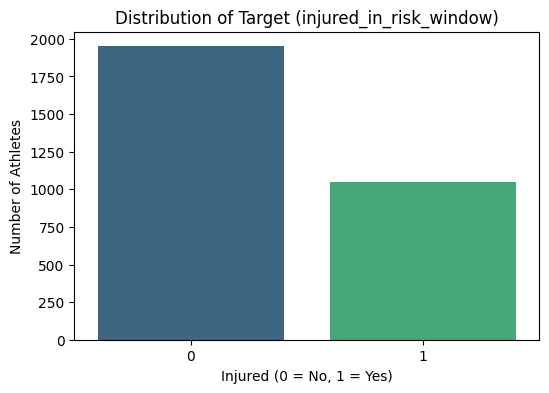

In [3]:
injury_counts = labels_df['injured_in_risk_window'].value_counts()
print(injury_counts)

plt.figure(figsize=(6, 4))
sns.barplot(x=injury_counts.index, y=injury_counts.values, palette='viridis')
plt.title('Distribution of Target (injured_in_risk_window)')
plt.xlabel('Injured (0 = No, 1 = Yes)')
plt.ylabel('Number of Athletes')
plt.show()

## 3. Load or Build Extracted Feature Dataset

In [4]:
import os
features_path = '../outputs/features.parquet'
if os.path.exists(features_path):
    features_df = pd.read_parquet(features_path)
    print('Loaded features:', features_df.shape)
else:
    print('Features file not yet built. Run feature_engineering.py to generate.')

Loaded features: (3000, 70)


## 4. Workload Spike vs Injury Correlation

/var/folders/rl/jjspnqnn4d7d0b7r1v032g7c0000gn/T/ipykernel_2724/3761868302.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


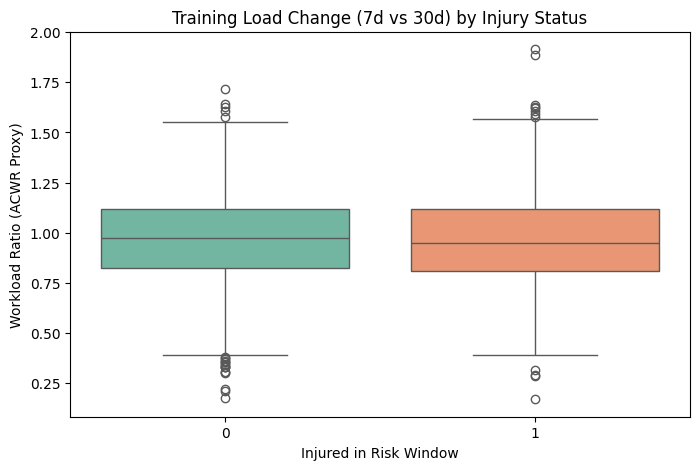

In [5]:
if 'features_df' in locals() and 'training_load_change_7d_vs_30d' in features_df.columns:
    plt.figure(figsize=(8, 5))
    sns.boxplot(
        data=features_df,
        x='injured_in_risk_window',
        y='training_load_change_7d_vs_30d',
        palette='Set2'
    )
    plt.title('Training Load Change (7d vs 30d) by Injury Status')
    plt.xlabel('Injured in Risk Window')
    plt.ylabel('Workload Ratio (ACWR Proxy)')
    plt.show()